**PERÍODO ACADÉMICO:** 2026-A  
**ASIGNATURA:** ICCD412 Métodos Numéricos  
**GRUPO:** GR2  
**TIPO DE INSTRUMENTO:** PROYECTO
**FECHA DE ENTREGA LÍMITE:** 03/07/2026  
**ALUMNO:** Jose Pallares, Jhosua Saa, Erick Toapanta.


### Etapa 1: Tratamiento de Datos

En esta primera etapa, preparamos el entorno de trabajo aislando la ventana temporal estricta de interés (octubre 2019 - octubre 2024) y limpiando el ruido a nivel de sistema para garantizar cálculos numéricos estables en las fases posteriores.

**Los desafíos identificados son:**
* **Filtrado Temporal:** Se aísla el periodo post-pandemia utilizando máscaras booleanas para trabajar únicamente con los 5 años exactos de interés.
* **Aritmética de Punto Flotante:** Se aplica un redondeo estricto a 8 decimales en el precio de cierre para mitigar el riesgo de acumulación de errores de truncamiento y propagación al resolver matrices.
* **Variable Independiente:** Los modelos matemáticos operan sobre ejes continuos en los números reales, no sobre objetos de calendario. Se crea la variable $t$, donde cada unidad de incremento representa un día hábil de operación bursátil.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

In [9]:

# --- 1. TRATAMIENTO DE DATOS ---
def tratamiento_datos(dataset_path):
    try:
        df_total = pd.read_csv(dataset_path)

        # Convertir la columna Date a formato fecha
        df_total['Date'] = pd.to_datetime(df_total['Date'])

        # FILTRADO (Oct 2019 - Oct 2024)
        fecha_inicio = pd.to_datetime('2019-10-01')
        fecha_fin = pd.to_datetime('2024-10-31')
        mascara = (df_total['Date'] >= fecha_inicio) & (df_total['Date'] <= fecha_fin)

        # Nos quedamos solo con los datos que cumplen la condición
        df_analisis = df_total.loc[mascara].sort_values('Date').reset_index(drop=True).copy()

        # Estandarización a 8 decimales por redondeo
        df_analisis['Close'] = df_analisis['Close'].round(8)

        # Creación de variable independiente t (días de operación)
        df_analisis['t'] = np.arange(len(df_analisis))

        t = df_analisis['t'].to_numpy()
        y = df_analisis['Close'].to_numpy()

        print("--- ETAPA 1: TRATAMIENTO COMPLETADO ---")
        print(f"Rango de datos: {df_analisis['Date'].min().date()} a {df_analisis['Date'].max().date()}")
        print(f"Total de registros (n): {len(df_analisis)}")
        print(f"Precio Mínimo: {df_analisis['Close'].min():.2f} | Precio Máximo: {df_analisis['Close'].max():.2f}")

    except Exception as e:
        print(f"Error al procesar los datos: {e}")

    return t, y, df_analisis['Date'].iloc[0]

### Etapa 2: Interpolación y Suavizado

En esta fase, reconstruimos la trayectoria del índice NASDAQ-100 mitigando las fluctuaciones de alta frecuencia (el "ruido" diario) para obtener una función continua que sea matemáticamente tratable sin perder la fidelidad de los datos reales.

**Interpretación Técnica:**
* **Fidelidad de los Datos:** A diferencia de un ajuste global, la curva generada en esta etapa intercepta exactamente cada registro de precio de cierre diario de la base de datos.
* **Continuidad y Suavidad:** Se implementan Splines Cúbicos en lugar de una interpolación polinómica tradicional para evitar las oscilaciones catastróficas en los extremos (Fenómeno de Runge). Esto garantiza que en cada nodo de unión, la primera y segunda derivada sean idénticas.
* **Vector Denso de Evaluación:** Se genera un espacio muestral de 1000 puntos para trazar una curva fluida que facilita la identificación visual de la inercia del mercado.

In [10]:
def splines(t, y):
    # Garantiza que la segunda derivada en los extremos sea cero
    spline = CubicSpline(t, y, bc_type='natural')

    # Generación de un espacio muestral denso para visualización fluida
    t_spline = np.linspace(t.min(), t.max(), 1000)
    y_spline = spline(t_spline)

    # Configuración del entorno gráfico estandarizado
    plt.figure(figsize=(10, 6))

    # Trazado de datos crudos con opacidad reducida para no saturar
    plt.plot(t, y, color='blue', alpha=0.5, linewidth=2, label='Precio Real (Ruido)')

    # Trazado de la curva interpolada
    plt.plot(t_spline, y_spline, color='green', alpha=0.8, linewidth=1, label='Suavizado (Spline Cúbico)')

    plt.title('Suavizado de la Dinámica de Precios del NASDAQ-100')
    plt.xlabel('Días Normalizados')
    plt.ylabel('Precio de Cierre (Puntos)')
    plt.legend()
    plt.grid(True)
    plt.show()

    return t_spline, y_spline

### Etapa 3: Determinación de la tendencia
Esta fase constituye en el uso del método de mínimos cuadrados para determinar un polinomio que se ajuste a la tendencia revisada en la etapa anterior posterior a suavizar la curva mediante Splines Cúbicos.

Se usará la hipótesis inicial que un polinomio de grado 4 pueda describir la tendencia dado el número de macro eventos descritos.

In [11]:
# ETAPA 3: REGRESIÓN POLINOMIAL (MÍNIMOS CUADRADOS)
def minimos_cuadrados(t, y, grado):
    num_coeficientes = grado + 1

    # Construcción de la matriz
    A = np.zeros((len(t), num_coeficientes))
    for i in range (0, num_coeficientes):
        for j in range(len(t)): 
            A[j][i] = t[j] ** i

    A_T = np.transpose(A)

    # Determinar el sistema cuadrado mediante el producto A^T A = A^T y 
    matriz_normal = np.dot(A_T, A)
    vector_normal = np.dot(A_T, y)

    # Resolver el sistema cuadrado
    coeficientes = np.linalg.solve(matriz_normal, vector_normal)
    y_pred = np.dot(A, coeficientes)

    # Gráfica
    plt.figure(figsize=(10, 6)) 
    plt.plot(t, y, color='blue', alpha=0.5, label='Precio Real (Ruido)')
    plt.plot(t, y_pred, color='red', linewidth=2, label='Tendencia (Mínimos Cuadrados)')
    plt.title('Ajuste de Tendencia del NASDAQ-100 mediante Mínimos Cuadrados')
    plt.xlabel('Días Normalizados')
    plt.ylabel('Precio de Cierre (Puntos)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Cálculo del coeficiente de determinación R^2
    # Promedio de los precios reales
    y_promedio = np.mean(y)

    # Suma total de los cuadrados (variabilidad total de los datos)
    SST = np.sum((y - y_promedio)**2)

    # Suma de los cuadrados de los residuos (error matemático del modelo)
    SSR = np.sum((y - y_pred)**2)

    # R^2 final
    r2 = 1 - (SSR / SST)

    print(f"Coeficiente de determinación R^2: {r2:.4f}")

    return coeficientes, r2

La función `optimizar grado polinomio` ejecuta mínimos cuadrados de manera iterativa disminuyendo el grado del polinomio y comparando los resultados obtenidos a través de los datos de prueba para recuperar el mejor modelo que se ajuste a la tendencia para predicción a través del coeficiente $R^2$

In [ ]:
def optimizar_grado_polinomio(t_entrenamiento, y_entrenamiento, t_prueba, y_prueba, grado_max=4):
    mejor_r2 = -float('inf')
    mejor_grado = 1
    mejores_coefs = None
    historial_modelos = {}

    for grado in range(grado_max, 0, -1):
        # 1. Entrenar el modelo con el 80% usando minimos cuadrados
        coefs, r2_entrenamiento = minimos_cuadrados(t_entrenamiento, y_entrenamiento, grado)
        
        # 2. Evaluar el error matemático con el 20% de prueba
        y_pred_test = sum(coefs[i] * t_prueba**i for i in range(len(coefs)))
        sst = np.sum((y_prueba - np.mean(y_prueba))**2)
        ssr = np.sum((y_prueba - y_pred_test)**2)
        r2_prueba = 1 - (ssr / sst)
        
        # Almacenar datos para la gráfica comparativa
        historial_modelos[grado] = {'coefs': coefs, 'r2_prueba': r2_prueba}
        
        print(f"Evaluando Grado {grado} -> R^2 Prueba: {r2_prueba:.4f}")
        
        # 3. Guardar el mejor modelo
        if r2_prueba > mejor_r2:
            mejor_r2 = r2_prueba
            mejores_coefs = coefs
            mejor_grado = grado
            
    print(f"\nModelo seleccionado: Polinomio de grado {mejor_grado}")            
    return mejor_grado, mejores_coefs, historial_modelos

### Etapa 4: Determinación del Punto Objetivo (Método de Newton-Raphson)

En esta etapa final se busca determinar el instante $t$ (día hábil de operación) en el cual el índice NASDAQ-100 alcanzaría un valor objetivo de **85 puntos**, utilizando como modelo matemático el polinomio de tendencia $P(t)$ obtenido en la Etapa 3 mediante mínimos cuadrados.

In [12]:
# ETAPA 4: MÉTODO DE NEWTON-RAPHSON
def newton_raphson(coeficientes, objetivo, t0, tol=1e-6, max_iter=100):
    # Definición local de la función
    def f(t_val):
        return sum(coeficientes[i] * t_val**i for i in range(len(coeficientes))) - objetivo
    # Definición local de la derivada
    def df(t_val):
        return sum(i * coeficientes[i] * t_val**(i - 1) for i in range(1, len(coeficientes)))

    historial = []
    t_actual = t0

    for i in range(1, max_iter + 1):
        f_t = f(t_actual)
        df_t = df(t_actual)

        # Criterio de seguridad: evitar división entre una derivada casi nula
        if abs(df_t) < 1e-12:
            print(f"Derivada cercana a cero en la iteración {i}. El método se detiene.")
            break

        t_siguiente = t_actual - f_t / df_t
        error = abs(t_siguiente - t_actual)
        historial.append((i, t_actual, f_t, t_siguiente, error))

        if error < tol:
            t_actual = t_siguiente
            break

        t_actual = t_siguiente

    return t_actual, historial


In [13]:
def visualizar_proyeccion(t_real, y_real, coeficientes, objetivo, t_raiz):
    def P(t_val):
        return sum(coeficientes[i] * (t_val ** i) for i in range(len(coeficientes)))

    t_vis = np.linspace(t_real.min(), t_raiz + 50, 1000)
    y_vis = P(t_vis)

    plt.figure(figsize=(10, 6))

    plt.plot(t_real, y_real, color='blue', alpha=0.3, label='Precio Real (Ruido)')
    plt.plot(t_vis, y_vis, color='red', linewidth=2, label='Tendencia (Mínimos Cuadrados) extrapolada')
    plt.axhline(y=objetivo, color='gray', linestyle='--', label=f'Objetivo = {objetivo} puntos')
    plt.axvline(x=t_raiz, color='green', linestyle='--', alpha=0.7)
    plt.scatter([t_raiz], [objetivo], color='green', zorder=5, label=f'Raíz t* = {t_raiz:.1f}')

    plt.title('Determinación del Momento de Alcance del Objetivo (Newton-Raphson)')
    plt.xlabel('Días Normalizados')
    plt.ylabel('Precio de Cierre (Puntos)')
    plt.legend()
    plt.grid(True)
    plt.show()

--- ETAPA 1: TRATAMIENTO COMPLETADO ---
Rango de datos: 2019-10-01 a 2024-10-25
Total de registros (n): 1340
Precio Mínimo: 24.29 | Precio Máximo: 75.24


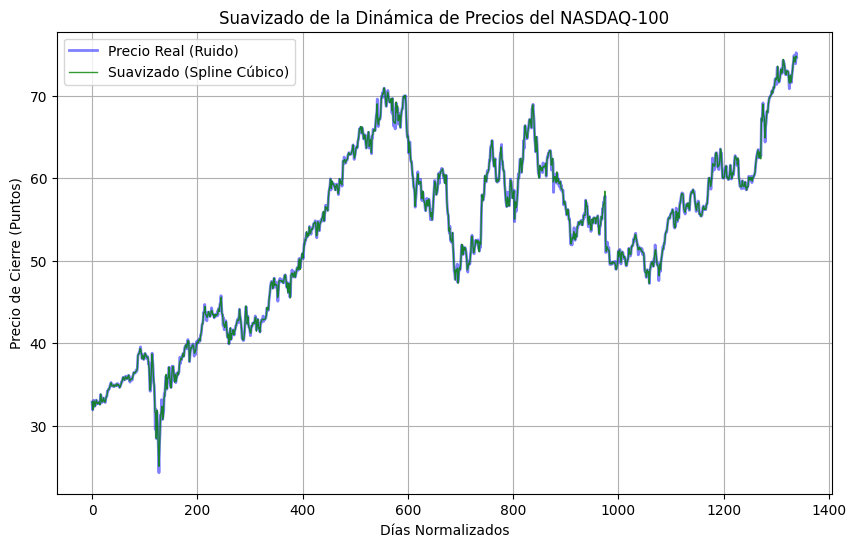

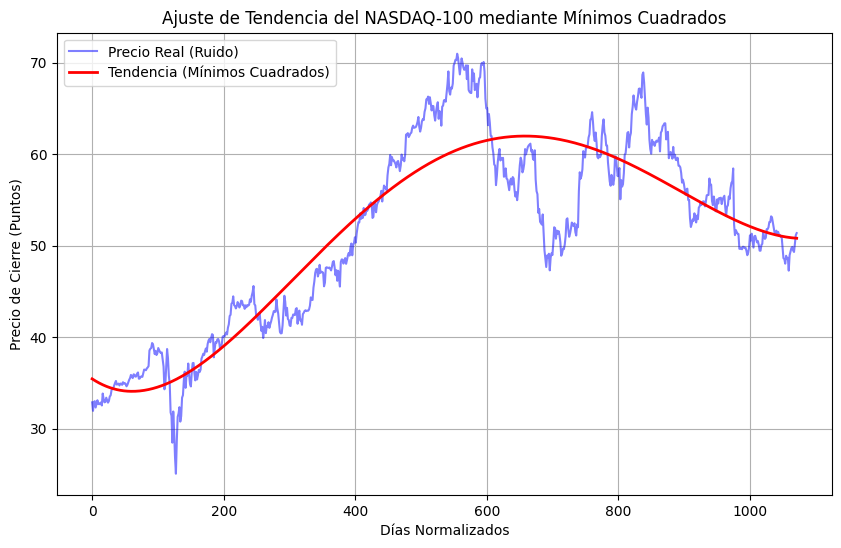

Coeficiente de determinación R^2: 0.8211
Validación completada. R^2 en Test (20%): -16.9155
Error Cuadrático Medio (RMSE): 28.15
Error Relativo Promedio: 43.89%

Cambio de signo detectado cerca de t = 1371.01. Se usa como semilla inicial.

--- ITERACIONES DEL MÉTODO DE NEWTON-RAPHSON ---
Iter  t_n            f(t_n)         t_n+1          Error       
1     1371.010670    -0.051661      1371.186703    1.76e-01    
2     1371.186703    0.000026       1371.186616    8.71e-05    
3     1371.186616    0.000000       1371.186616    2.16e-11    

Raíz encontrada: t* = 1371.1866 días hábiles
Verificación: P(t*) = 85.0000 (objetivo = 85)

Fecha estimada en la que el índice superaría los 85 puntos: 2025-01-01


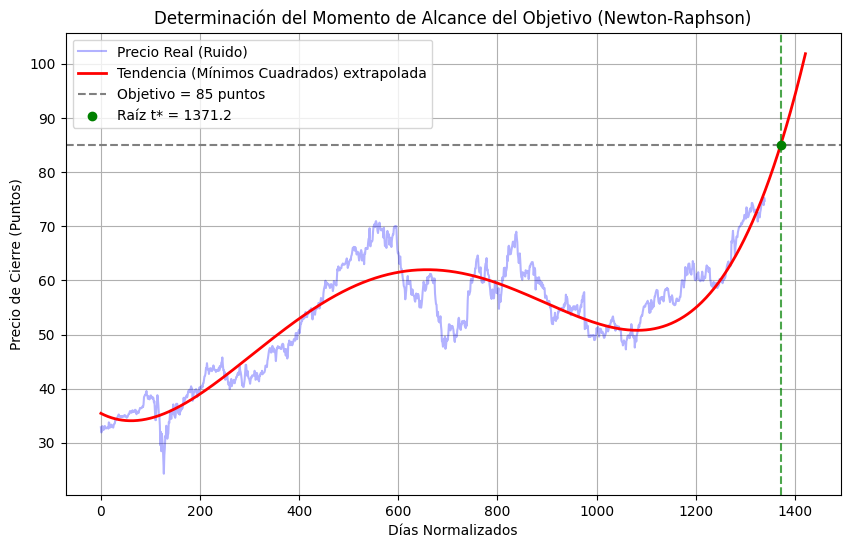

In [14]:
if __name__ == "__main__":
    # 1. Preparación de datos
    t_real, y_real, fecha_inicio = tratamiento_datos('../../DATASET/NASDAQ100.csv')
    
    # 2. Suavizado con splines
    t_spline, y_spline = splines(t_real, y_real)

    # 2.5. Segmentación Hold-Out(80/20)
    indice_corte = int(len(t_spline) * 0.8)
    t_entrenamiento = t_spline[:indice_corte]
    y_entrenamiento = y_spline[:indice_corte]
    t_prueba = y_spline[indice_corte:]
    y_prueba = y_spline[indice_corte:]
    
    # 3. Mínimos cuadrados
    coefs, r_cuadrado = minimos_cuadrados(t_entrenamiento, y_entrenamiento, grado=4)
    
    # 3.5 Validación con 20% de prueba
    y_pred_prueba = sum(coefs[i] * t_prueba**i for i in range(len(coefs)))

    SST_prueba = np.sum((y_prueba - np.mean(y_prueba))**2)
    SSR_prueba = np.sum((y_prueba - y_pred_prueba)**2)
    r2_prueba = 1 - (SSR_prueba / SST_prueba)
    
    rmse_prueba = np.sqrt(np.mean((y_prueba - y_pred_prueba)**2))
    error_relativo_promedio = np.mean(np.abs((y_prueba - y_pred_prueba) / y_prueba)) * 100
    
    print(f"Validación completada. R^2 en Test (20%): {r2_prueba:.4f}")
    print(f"Error Cuadrático Medio (RMSE): {rmse_prueba:.2f}")
    print(f"Error Relativo Promedio: {error_relativo_promedio:.2f}%")

    # 4. Preparación para Newton - Raphson
    punto_objetivo = 85
    t_max_datos = t_real.max()
    
    # 5. Búsqueda de un intervalo con cambio de signo (acota la semilla t0)
    t_exploracion = np.linspace(t_max_datos, t_max_datos + 1500, 3000)
    valores_g = sum(coefs[i] * t_exploracion**i for i in range(len(coefs))) - punto_objetivo

    cambio_signo = np.where(np.diff(np.sign(valores_g)) != 0)[0]

    if len(cambio_signo) > 0:
        t0 = t_exploracion[cambio_signo[0]]
        print(f"\nCambio de signo detectado cerca de t = {t0:.2f}. Se usa como semilla inicial.")
    else:
        t0 = t_max_datos
        print("\nNo se detectó cambio de signo; se usa el último día como semilla.")

    # 6. Ejecución del método de Newton-Raphson (Usando la cerradura nueva)
    t_raiz, historial = newton_raphson(coefs, punto_objetivo, t0)

    # 7. Tabla de iteraciones
    print("\n--- ITERACIONES DEL MÉTODO DE NEWTON-RAPHSON ---")
    print(f"{'Iter':<6}{'t_n':<15}{'f(t_n)':<15}{'t_n+1':<15}{'Error':<12}")
    for it in historial:
        print(f"{it[0]:<6}{it[1]:<15.6f}{it[2]:<15.6f}{it[3]:<15.6f}{it[4]:<12.2e}")

    print(f"\nRaíz encontrada: t* = {t_raiz:.4f} días hábiles")
    
    # Comprobación de la raíz (P(t*))
    valor_comprobacion = sum(coefs[i] * t_raiz**i for i in range(len(coefs)))
    print(f"Verificación: P(t*) = {valor_comprobacion:.4f} (objetivo = {punto_objetivo})")

    # 8. Conversión del resultado (t) a una fecha calendario
    fecha_estimada = fecha_inicio + pd.offsets.BDay(round(t_raiz))
    print(f"\nFecha estimada en la que el índice superaría los {punto_objetivo} puntos: {fecha_estimada.date()}")
    
    # 9.VDASisualización
    visualizar_proyeccion(t_real, y_real, coefs, punto_objetivo, t_raiz)